<h4><b>Asignatura:</b> Procesamiento Natural del Lenguaje.<br>
<b>Docente:</b> James Tomalá.<br>
<b>Institución:</b> IPP.<br>
<b>Fecha de Entrega:</b> 15 de Julio del 2026<br>
<b>Estudiante:</b> Jason Andrés Urrutia Orellana.</h4>

<h5><b>CONTEXTO: </b><em>Una vez lograda la representación vectorial del texto, se argumenta que ahora sí se
ha conseguido una data estructurada gracias al preprocesamiento de texto, y que este
resultado, a su vez, puede ser INPUT para un modelo. Una vez más, alguien del
equipo expresa que quiere aplicar una regresión lineal, a lo que contestamos que no
se puede porque el target de este problema no es numérico, y más bien hay que
ponerse a trabajar en un modelo supervisado para clasificación. ¿Qué modelos se
aplicarán?</em></h5>

<h2><b>CONSIGNAS</b></h2>

<p><b>1.</b><em> Aplicar modelo de clasificación machine learning</em></p>

<p> pero primero utilizaremos la clase Word2Vec para vectorizar todos los comentarios que previamente preprocesé y lematicé</p>

In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from gensim.models import Word2Vec
from ast import literal_eval
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.svm import SVC
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
classification_report, confusion_matrix, ConfusionMatrixDisplay)
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.decomposition import PCA

In [2]:
comentarios = pd.read_csv("comentarios_procesados.csv")

In [3]:
type(comentarios["lemmas"].iloc[0])

str

<p>Word2Vec trabaja con listas, y no con strings, por ende, con literal_eval, haré esta transformación</p>

In [4]:
comentarios["lemmas"] = comentarios["lemmas"].apply(literal_eval)

In [5]:
type(comentarios["lemmas"].iloc[0])

list

In [6]:
comentarios.info

<bound method DataFrame.info of      orden                                         comentario   tipo  \
0        1                                No les creo nada ,    malo   
1        2                          Está bonita la camioneta   bueno   
2        3                             Quiero más información   info   
3        4            :( igual el crédito ha de ser muuuucho    malo   
4        5  Quisiera, más información, pero nadie me respo...   info   
..     ...                                                ...    ...   
595    596  piezas de respuestos escasas y demoran mucho e...   malo   
596    597                    No sube muy bien las pendientes   malo   
597    598                     es la mejor SUV que he tenido   bueno   
598    599                el crédito directo resulta muy caro   malo   
599    600                      la recomiendo a ojos cerrados  bueno   

                                                tokens  \
0                                       ['no'

In [7]:
comentarios["lemmas"].head()

0                                [no, creer]
1                        [bonito, camioneto]
2                      [querer, información]
3        [:(, igual, crédito, ser, muuuucho]
4    [querer, información, nadie, responder]
Name: lemmas, dtype: object

In [8]:
comentarios_tokenizados = comentarios["lemmas"]

In [9]:
modelo_w2v = Word2Vec(sentences = comentarios_tokenizados, vector_size = 50,
window = 3, min_count = 1, workers = 4, sg = 0)

In [10]:
modelo_w2v.wv.most_similar("información")

[('necesito', 0.31438204646110535),
 ('doble', 0.2978147864341736),
 ('preferir', 0.296041339635849),
 ('maravilloso', 0.2851267457008362),
 ('muuuucho', 0.27547943592071533),
 ('final', 0.263611376285553),
 ('carretero', 0.2511008679866791),
 ('directo', 0.2502719759941101),
 ('además', 0.2314632534980774),
 ('joyo', 0.23076321184635162)]

In [11]:
def vectorizar_palabras(palabras, modelo):
    palabras = [palabra for palabra in palabras if palabra in modelo.wv]
    if len(palabras) == 0:
        return np.zeros(modelo.vector_size)
    return np.mean([modelo.wv[palabra] for palabra in palabras], axis = 0)

In [33]:
x = np.array(comentarios["lemmas"].apply(lambda x: vectorizar_palabras(x, modelo_w2v)).tolist())
x.shape

(600, 50)

In [13]:
y = comentarios["tipo"]

In [14]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.20, stratify = y)

<p>Decidí para esta ocasión hacer uso de 2 tipos de clasificación, 1.- <b>Support vector machine</b>, utilizando su clase para clasificacion SVC(Support Vector Classification). y 2.- <b>Gradient Boost.</b> Para poder hacer una comparativa de rendimientos con cada modelo.</p>

In [15]:
pipeline_svm = Pipeline([("scaler", StandardScaler()),
("svm", SVC(kernel="linear", class_weight="balanced"))])

In [16]:
pipeline_svm.fit(x_train, y_train)
y_pred = pipeline_svm.predict(x_test)

In [17]:
g_boost = GradientBoostingClassifier()
g_boost.fit(x_train, y_train)

,loss,'log_loss'
,learning_rate,0.1
,n_estimators,100
,subsample,1.0
,criterion,'friedman_mse'
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_depth,3
,min_impurity_decrease,0.0
,init,None


In [18]:
y_pred_gb = g_boost.predict(x_test)

<p>Une vez creados ambos modelos, lo que haré será una función que permita evaluar, y, eventualmente, comparar los rendimientos de los mismos</p>

In [24]:
def evaluar_modelo(modelo, x_test, x_train):
    y_pred = modelo.predict(x_test)
    """Métricas"""
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, average = "weighted")
    recall = recall_score(y_test, y_pred, average = "weighted")
    f1 = f1_score(y_test, y_pred, average = "weighted")

    print(f"Accuracy:", {accuracy})
    print(f"Precision:", {precision})
    print(f"Recall:", {recall})
    print(f"F1:", {f1})

    print("---------------------\nClassification Report\n")

    print(classification_report(y_test, y_pred))

    ConfusionMatrixDisplay.from_predictions(y_test, y_pred, cmap="Greens")

    plt.show()

    return {"Accuracy": accuracy, "Precision": precision, "Recall": recall, "F1-score": f1}

Accuracy: {1.0}
Precision: {1.0}
Recall: {1.0}
F1: {1.0}
---------------------
Classification Report

              precision    recall  f1-score   support

       bueno       1.00      1.00      1.00        44
        info       1.00      1.00      1.00        22
        malo       1.00      1.00      1.00        54

    accuracy                           1.00       120
   macro avg       1.00      1.00      1.00       120
weighted avg       1.00      1.00      1.00       120



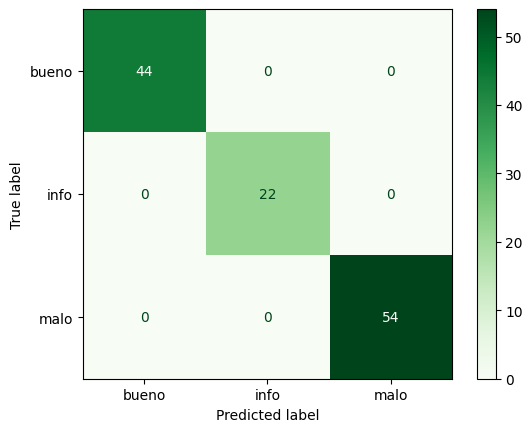

In [25]:
resultado_svm = evaluar_modelo(pipeline_svm, x_test, y_test)

Accuracy: {1.0}
Precision: {1.0}
Recall: {1.0}
F1: {1.0}
---------------------
Classification Report

              precision    recall  f1-score   support

       bueno       1.00      1.00      1.00        44
        info       1.00      1.00      1.00        22
        malo       1.00      1.00      1.00        54

    accuracy                           1.00       120
   macro avg       1.00      1.00      1.00       120
weighted avg       1.00      1.00      1.00       120



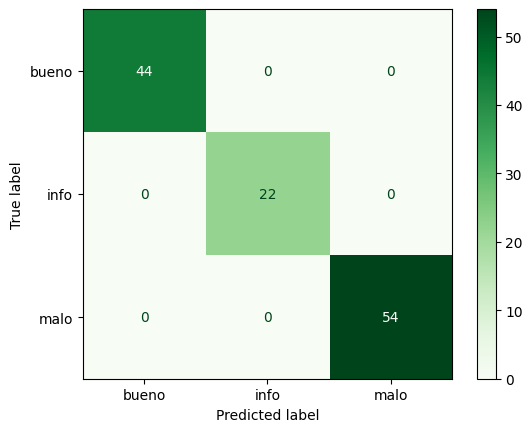

In [26]:
resultado_gb = evaluar_modelo(g_boost, x_test, y_test)

In [35]:
pca = PCA(n_components=2)
x_pca = pca.fit_transform(x)

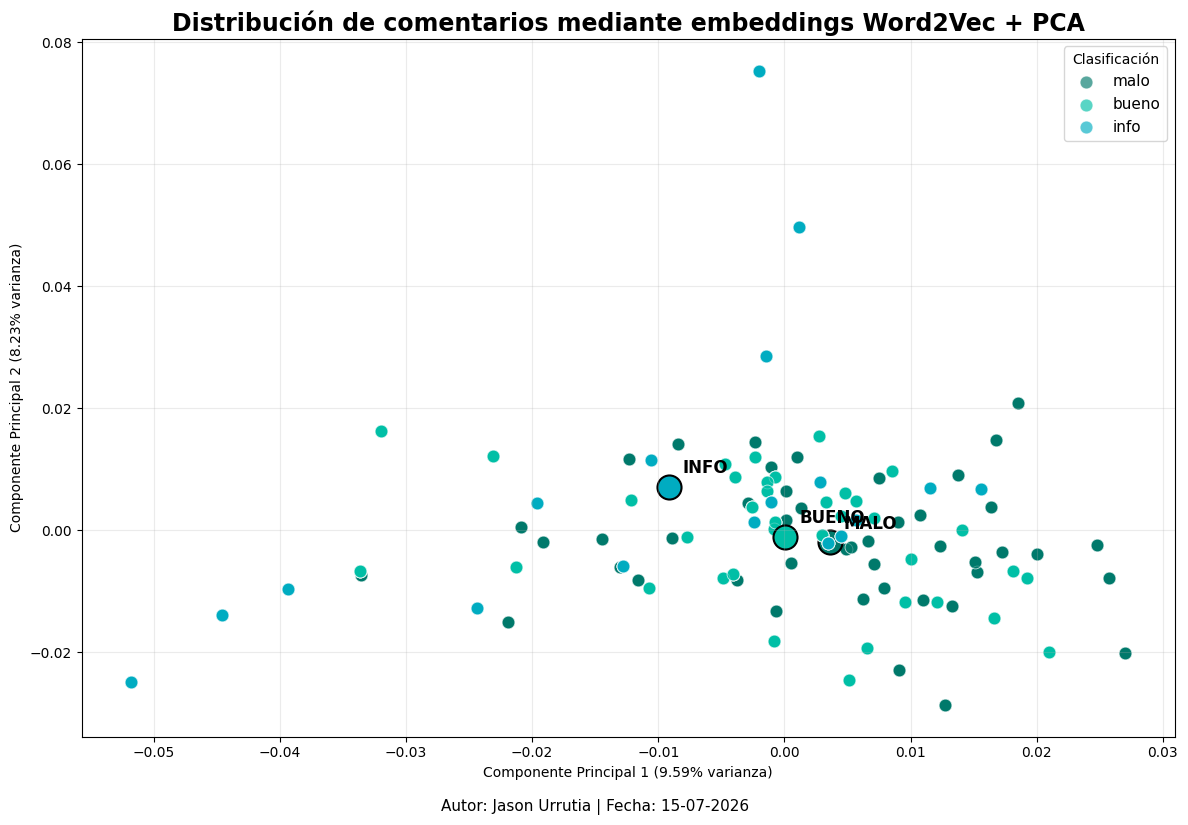

In [38]:
df_pca = pd.DataFrame({"PC1": x_pca[:, 0], "PC2": x_pca[:, 1], "tipo": y.values})
colores = {"bueno": "#00BFA6", "info": "#00ACC1","malo": "#00796B"}

plt.figure(figsize=(12, 8))
for clase in df_pca["tipo"].unique():
    datos = df_pca[df_pca["tipo"] == clase]
    color = colores.get(clase, "#00CED1")
    plt.scatter(datos["PC1"], datos["PC2"], c=color, label=clase, s=85,
                alpha=0.65, edgecolors="white", linewidth=0.6)
    centroide_x = datos["PC1"].mean()
    centroide_y = datos["PC2"].mean()
    plt.scatter(centroide_x, centroide_y, c=color, s=300,
marker="o", edgecolors="black", linewidth=1.5)
    plt.annotate(clase.upper(),(centroide_x, centroide_y), xytext=(10,10),
                textcoords="offset points", fontsize=12, weight="bold")
plt.title(
    "Distribución de comentarios mediante embeddings Word2Vec + PCA", fontsize=17, weight="bold")
plt.xlabel(f"Componente Principal 1 ({pca.explained_variance_ratio_[0]*100:.2f}% varianza)")
plt.ylabel(f"Componente Principal 2 ({pca.explained_variance_ratio_[1]*100:.2f}% varianza)")
plt.legend(title="Clasificación",fontsize=11)
plt.grid(alpha=0.25)
plt.figtext(0.5, -0.02, "Autor: Jason Urrutia | Fecha: 15-07-2026", ha="center", fontsize=11)
plt.tight_layout()
plt.show()

<h2>Resultados del modelo</h2>

<p>Luego del preprocesamiento del texto y la generación de embeddings mediante 
<b>Word2Vec</b>, se aplicaron dos modelos supervisados de clasificación 
multinomial: <b>Support Vector Machine (SVM)</b> y <b>Gradient Boosting</b>.</p>

<table>
  <tr>
    <th>Modelo</th>
    <th>Accuracy</th>
    <th>Precision</th>
    <th>Recall</th>
    <th>F1-score</th>
  </tr>
  <tr>
    <td>SVM</td>
    <td>1.00</td>
    <td>1.00</td>
    <td>1.00</td>
    <td>1.00</td>
  </tr>
  <tr>
    <td>Gradient Boosting</td>
    <td>1.00</td>
    <td>1.00</td>
    <td>1.00</td>
    <td>1.00</td>
  </tr>
</table>

<p>Ambos modelos lograron clasificar correctamente las tres categorías del problema:
<b>bueno</b>, <b>malo</b> e <b>info</b>, obteniendo un rendimiento
perfecto sobre la muestra de evaluación.</p>

<p>Finalmente, se realizó una reducción dimensional mediante <b>PCA</b> para
visualizar la distribución de los embeddings generados por Word2Vec en un espacio
bidimensional.</p>